In [1]:
import joblib

X_train = joblib.load("X_train.pkl")
X_val = joblib.load("X_val.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_val = joblib.load("y_val.pkl")
y_test = joblib.load("y_test.pkl")

X_train_scaled = joblib.load("X_train_scaled.pkl")
X_val_scaled = joblib.load("X_val_scaled.pkl")
X_test_scaled = joblib.load("X_test_scaled.pkl")

In [3]:
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.66)

def categorize(value):
    if value <= q1:
        return 0
    elif value <= q2:
        return 1
    else:
        return 2

y_train_class = y_train.apply(categorize)
y_val_class = y_val.apply(categorize)
y_test_class = y_test.apply(categorize)

print("Class distribution:")
print(y_train_class.value_counts())

Class distribution:
MedHouseVal
2    4910
0    4771
1    4767
Name: count, dtype: int64


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train_class)

val_pred_log = log_model.predict(X_val_scaled)

print("Validation Accuracy (Logistic):",
      accuracy_score(y_val_class, val_pred_log))

Validation Accuracy (Logistic): 0.7131782945736435


In [7]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_class)

val_pred_dt = dt_model.predict(X_val)

print("Validation Accuracy (Decision Tree):",
      accuracy_score(y_val_class, val_pred_dt))

Validation Accuracy (Decision Tree): 0.7231912144702842


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train_class)

val_pred_rf = rf_model.predict(X_val)

print("Validation Accuracy (Random Forest):",
      accuracy_score(y_val_class, val_pred_rf))

Validation Accuracy (Random Forest): 0.8020025839793282


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

test_pred = rf_model.predict(X_test)

print("Test Accuracy:",
      accuracy_score(y_test_class, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, test_pred))

print("\nClassification Report:")
print(classification_report(y_test_class, test_pred))

Test Accuracy: 0.8226744186046512

Confusion Matrix:
[[885 121  14]
 [132 749 128]
 [ 18 136 913]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1020
           1       0.74      0.74      0.74      1009
           2       0.87      0.86      0.86      1067

    accuracy                           0.82      3096
   macro avg       0.82      0.82      0.82      3096
weighted avg       0.82      0.82      0.82      3096



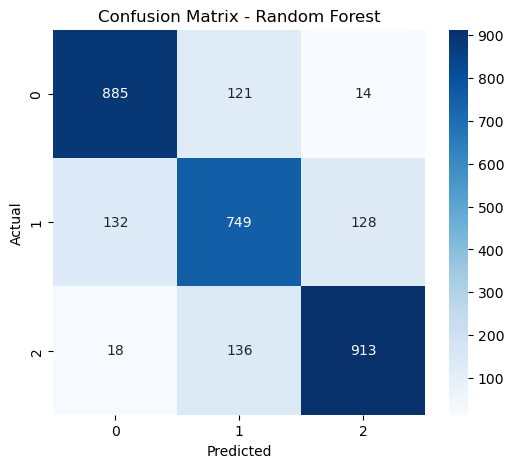

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_class, test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [16]:
joblib.dump(rf_model, "classification_model.pkl")
print("Classification model saved!")

Classification model saved!
